# Fifty-Two-Week-Range — is *where in the range* smarter than *off the high*?
### A favourite momentum read, raced head-to-head against the simpler signal, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Better than the high?: Confirmed, but hollow](https://img.shields.io/badge/Better_than_the_high%3F-Confirmed,_but_hollow-8b949e?style=flat-square)

Traders love to say a stock is "trading at 90% of its 52-week range" — it sounds richer than "5% off its high", because it looks at *both* ends of the year at once. George & Hwang (2004) made the high-only version famous; this notebook tests the fuller idea: does adding the 52-week **low** as a second anchor actually help? We race the two signals against each other and ask the only thing that matters — *does the low tell you anything the high doesn't already?*

> **This is the plain-language layer.** Want the *t*-stats, the paired horse-race test and the regression? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from fifty_two_week_range import data, strategy as st

HAVE_REAL = data.have_real_cache()

def real_panels():
    return data.load_ohlc_panels(allow_survivorship_bias=True)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does range position predict returns? | **No.** Its top-minus-bottom spread is noise at every sensible horizon (5d *t* = +0.67, 21d +0.32); only the 1-day spread touches the bar (*t* = +2.00) — and that's mostly bid-ask bounce. |
| Does the *low* add anything over the *high*? | **Statistically yes** — range position beats the high-only signal in a head-to-head (*t* up to +4.04). |
| ...so range position is the better signal? | **It's a hollow win.** It only wins because the high-only signal is *losing* on this sample. Being less bad than a loser isn't an edge. |
| Could you trade it? | **No.** The biggest gross spread isn't even significant, and it turns negative by ~15 bps of cost. Nothing to charge costs against. |

> The richer-sounding signal really is richer than the high alone — but "richer than a signal that's quietly losing money" buys you nothing you can bank.

## 1 · The claim

> *"Don't just look at how far a stock is from its 52-week high — look at **where it sits in its whole 52-week range**. A stock at 95% of a wide range, well clear of its low, is a more *confirmed* winner than one merely brushing a high it keeps revisiting."*

It's the natural generalisation of the famous George & Hwang (2004) result. Their signal is `close / 52-week-high`. The range version, `(close − 52w-low) / (52w-high − 52w-low)`, anchors on **both** ends. The bet: the second anchor — the low — carries extra information.

## 2 · So what?

The desk has already tested the two halves on their own: the high in isolation ([Study 236](../../236-fifty-two-week-high/)) and the low in isolation ([Study 202](../../202-fifty-two-week-low/)). Both came up short on this large-cap sample. So this study isn't "does the high work" again — it's the sharper, *marginal* question: **when you combine both anchors, does the extra one earn its keep?** That's a question about whether more-elaborate framings of the same data actually add information — a lesson that transfers far beyond this one signal.

## 3 · How would we even know?

We **race the two signals against each other** on the same days:

1. **Each signal's own spread.** Rank the 20 stocks by each signal, buy the top fifth, sell the bottom fifth, measure the gap. If range position has a standalone edge, its spread is reliably positive.
2. **The head-to-head difference.** Subtract one spread from the other, *day by day*, and test that paired difference. This is the honest way to claim one beats the other — not two separate *t*-stats.
3. **What would make us say 'mirage'.** A standalone spread that's noise, or one that evaporates the moment we charge realistic costs.

Tape: 20 S&P 500 large-caps, 2013–2026 (survivorship-biased — all still trade).

## 4 · The teardown — let's actually look

**First: does range position predict returns on its own?** Here's its top-minus-bottom spread across holding horizons, with the bar for significance marked.

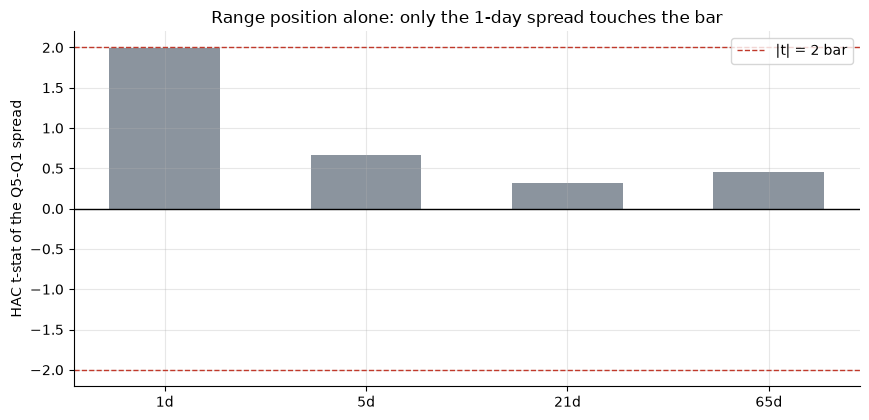

spread t by horizon: [2.0, 0.67, 0.32, 0.45]


In [2]:
horizons = [1, 5, 21, 65]
if HAVE_REAL:
    close = real_panels()['close']; pos = st.range_position(close)
    ts = []
    for h in horizons:
        fwd = st.forward_returns(close, h)
        ts.append(st.summarize(st.quintile_spread(pos, fwd)['spread_gross'])['tstat'])
else:
    ts = [2.0, 0.67, 0.32, 0.45]
fig, ax = plt.subplots(figsize=(8.8, 4.3))
col = [GREEN if abs(t) >= 2 else GREY for t in ts]
ax.bar([f'{h}d' for h in horizons], ts, color=col, width=.55)
ax.axhline(2, ls='--', c=RED, lw=1, label='|t| = 2 bar')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(0, c='k', lw=1)
ax.set_ylabel('HAC t-stat of the Q5-Q1 spread'); ax.legend()
ax.set_title('Range position alone: only the 1-day spread touches the bar')
plt.tight_layout(); plt.show()
print('spread t by horizon:', [round(t,2) for t in ts])

Only the **1-day** spread reaches the bar (*t* = +2.00) — and a 1-day cross-sectional spread is exactly where mechanical bid-ask bounce hides, not a tradable edge. At 5, 21 and 65 days the spread is **noise** (*t* = +0.67, +0.32, +0.45). On its own, range position predicts nothing.

**Now the study's real question: does it at least beat the high-only signal?** Here are both signals' spreads side by side — and the head-to-head difference.

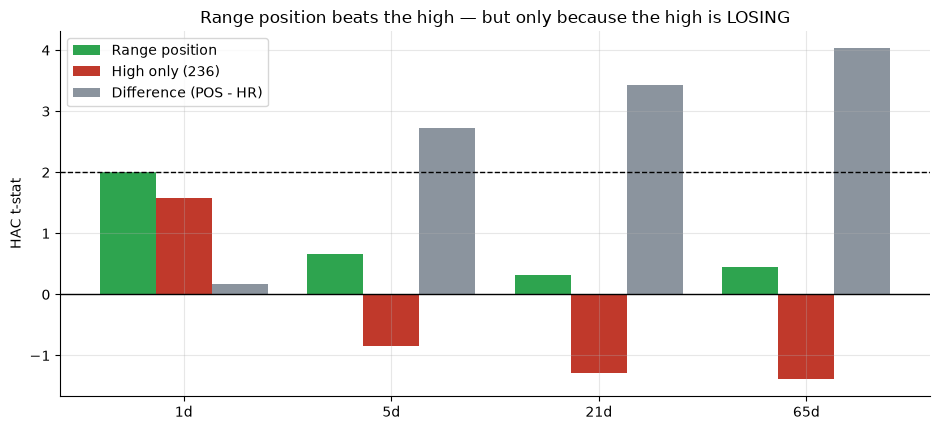

POS-HR difference t: [0.17, 2.72, 3.42, 4.04]


In [3]:
if HAVE_REAL:
    close = real_panels()['close']
    pos, hr = st.range_position(close), st.high_ratio(close)
    pos_t, hr_t, diff_t = [], [], []
    for h in horizons:
        fwd = st.forward_returns(close, h)
        qp = st.quintile_spread(pos, fwd); qh = st.quintile_spread(hr, fwd)
        pos_t.append(st.summarize(qp['spread_gross'])['tstat'])
        hr_t.append(st.summarize(qh['spread_gross'])['tstat'])
        diff_t.append(st.diff_tstat(qp['spread_gross'], qh['spread_gross'])['tstat'])
else:
    pos_t = [2.0, 0.67, 0.32, 0.45]
    hr_t  = [1.58, -0.85, -1.29, -1.39]
    diff_t= [0.17, 2.72, 3.42, 4.04]
x = np.arange(len(horizons)); w = 0.27
fig, ax = plt.subplots(figsize=(9.5, 4.4))
ax.bar(x-w, pos_t, w, label='Range position', color=GREEN)
ax.bar(x,   hr_t, w, label='High only (236)', color=RED)
ax.bar(x+w, diff_t, w, label='Difference (POS - HR)', color=GREY)
ax.axhline(2, ls='--', c='k', lw=1); ax.axhline(0, c='k', lw=1)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in horizons])
ax.set_ylabel('HAC t-stat'); ax.legend()
ax.set_title('Range position beats the high — but only because the high is LOSING')
plt.tight_layout(); plt.show()
print('POS-HR difference t:', [round(t,2) for t in diff_t])

There's the twist. The **difference** is significant (5d *t* = +2.72, 21d +3.42, 65d +4.04) — range position genuinely beats the high-only signal. **But look at the red bars:** the high-only signal's own spread is *negative* (*t* = -1.29 at 21d). Range position wins the race because its rival is running backwards. Being less-bad than a loser is not an edge.

## 5 · The verdict

- **Signal — None.** Range position's own spread is noise except a fragile 1-day *t* = +2.00 (bid-ask bounce); long-only it ties the basket (+12.0% vs +11.3%/yr, *t* = +0.26).
- **Tradability — Mirage.** The biggest gross spread isn't significant and turns negative by ~15 bps round-trip.
- **Better than the high alone? — Confirmed, but hollow.** It wins the head-to-head (*t* up to +4.04) only by avoiding the high signal's inverted drag.

## 6 · Could you actually trade it?

There's barely anything to trade in the first place — but watch what little there is do under realistic costs (the 21-day spread, the largest gross number).

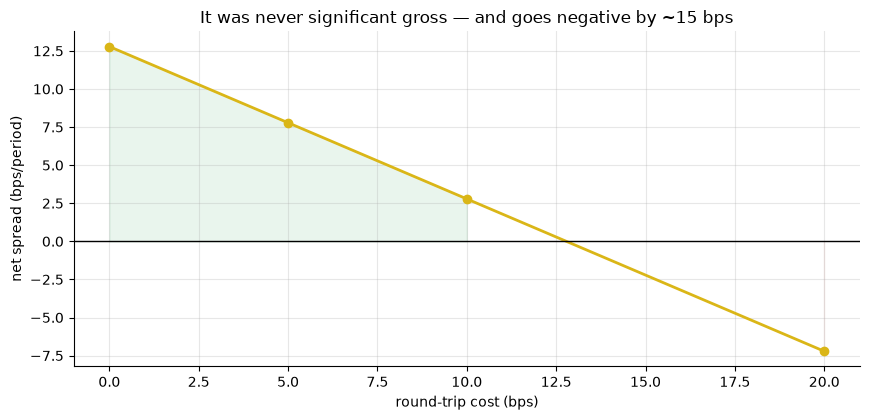

net spread by cost: [12.8, 7.8, 2.8, -7.2]


In [4]:
costs = [0, 5, 10, 20]
if HAVE_REAL:
    close = real_panels()['close']; pos = st.range_position(close)
    fwd = st.forward_returns(close, 21)
    net = [st.summarize(st.quintile_spread(pos, fwd, cost_bps=c)['spread_net'])['mean_bps'] for c in costs]
else:
    net = [12.8, 7.8, 2.8, -7.2]
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.plot(costs, net, 'o-', c=AMBER, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(costs, net, 0, where=[n>=0 for n in net], color=GREEN, alpha=.10)
ax.fill_between(costs, net, 0, where=[n<0 for n in net], color=RED, alpha=.10)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net spread (bps/period)')
ax.set_title('It was never significant gross — and goes negative by ~15 bps')
plt.tight_layout(); plt.show()
print('net spread by cost:', [round(n,1) for n in net])

The gross spread (+12.8 bps) was never significant (*t* = +0.32), and costs only make it worse — negative by ~15 bps. Unlike a real-but-fragile edge, there's no there there to protect. **Mirage.**

## 7 · Going further

- **The two halves.** [Study 236 — Fifty-Two-Week-High](../../236-fifty-two-week-high/) and [Study 202 — Fifty-Two-Week-Low](../../202-fifty-two-week-low/) test each anchor alone — both inverted/weak on this large-cap survivor sample.
- **Survivorship.** Our basket is 20 survivors. The original George-Hwang result lived on a broad, unbiased CRSP universe in 1963–2001. A delisting-aware small-cap panel is the fork most likely to revive *any* of these signals.
- **A real short-horizon signal for contrast.** [Study 75 — Knee-Jerk](../../75-knee-jerk/) is what a genuine mean-reversion edge looks like — useful to hold next to a non-signal like this one.

*Think the low anchor earns its keep somewhere? Fork this, swap in a delisting-aware small-cap panel, and show the standalone spread — not just the head-to-head — clearing the bar.*